In [32]:
import pandas as pd

In [33]:
df=pd.read_csv("heart_disease.csv")

In [34]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0
...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   object 
 2   Blood Pressure       1000 non-null   object 
 3   Cholesterol          1000 non-null   object 
 4   Glucose              1000 non-null   object 
 5   Smoking              1000 non-null   object 
 6   Alcohol Consumption  1000 non-null   object 
 7   Exercise             1000 non-null   object 
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   object 
 10  Heart Disease        1000 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 86.1+ KB


In [36]:
df.describe()

,Age,BMI,Heart Disease
count,1000.000000,1000.000000,1000.000000
mean,52.881000,29.213037,0.253000
std,20.958915,6.196368,0.434948
min,18.000000,18.504881,0.000000
25%,34.750000,23.924004,0.000000
50%,52.500000,28.892349,0.000000
75%,71.000000,34.663806,1.000000
max,89.000000,39.974048,1.000000


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
numerical_df = df.select_dtypes(include=['number']).drop(columns=['Heart Disease'])
display(numerical_df.head())

,Age,BMI
0,69,35.671099
1,32,38.554188
2,89,18.932964
3,78,21.806350
4,38,37.552683


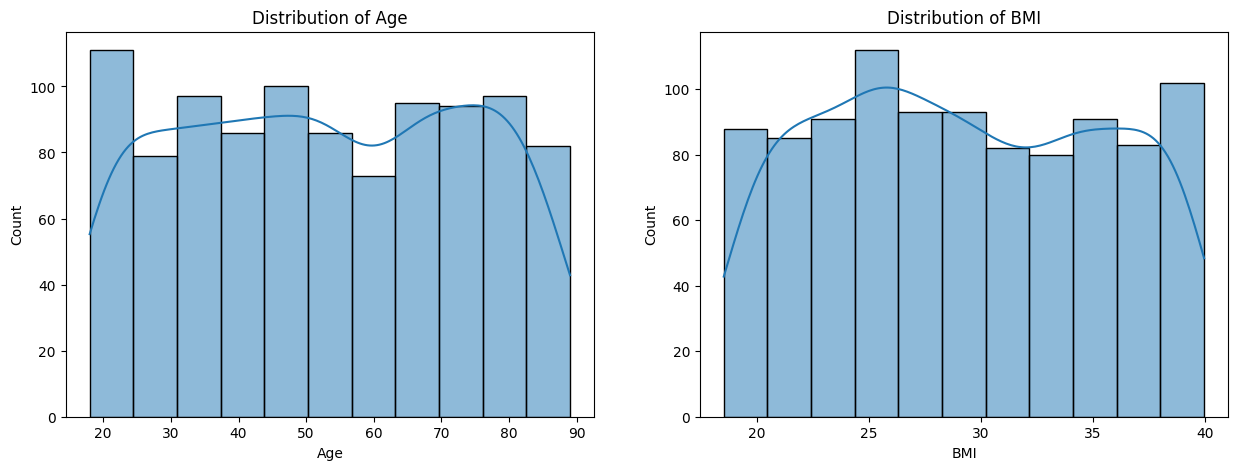

In [39]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 2, 2)
sns.histplot(df['BMI'], kde=True)
plt.title('Distribution of BMI')
plt.show()

In [40]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking', 'Alcohol Consumption', 'Exercise', 'Family History']


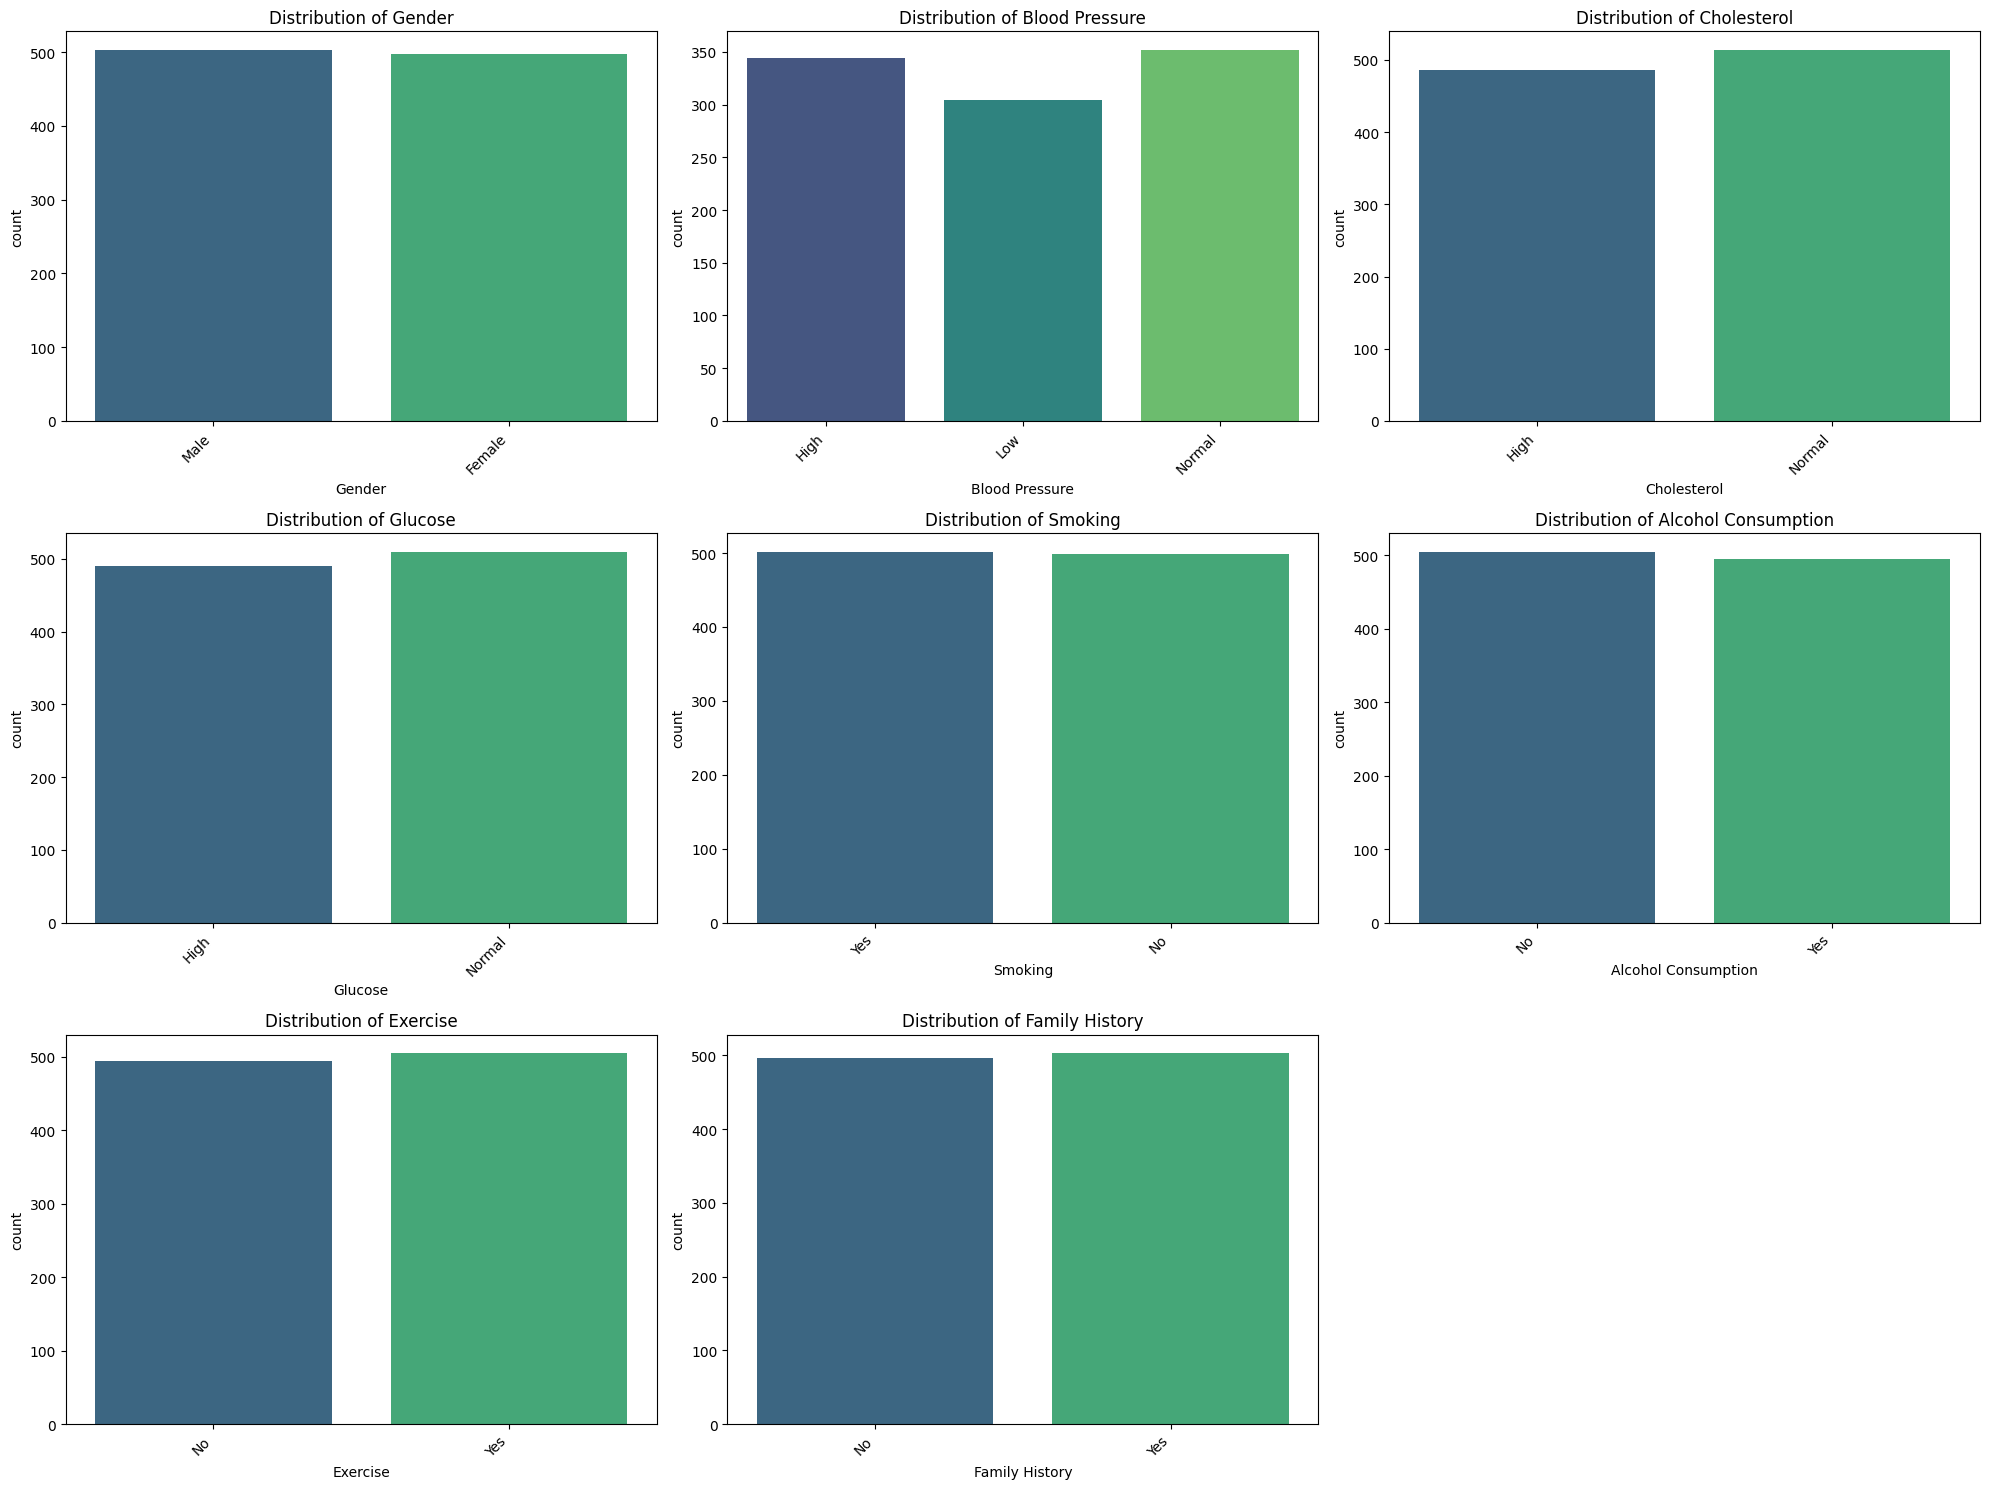

In [41]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=df, palette='viridis', hue=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

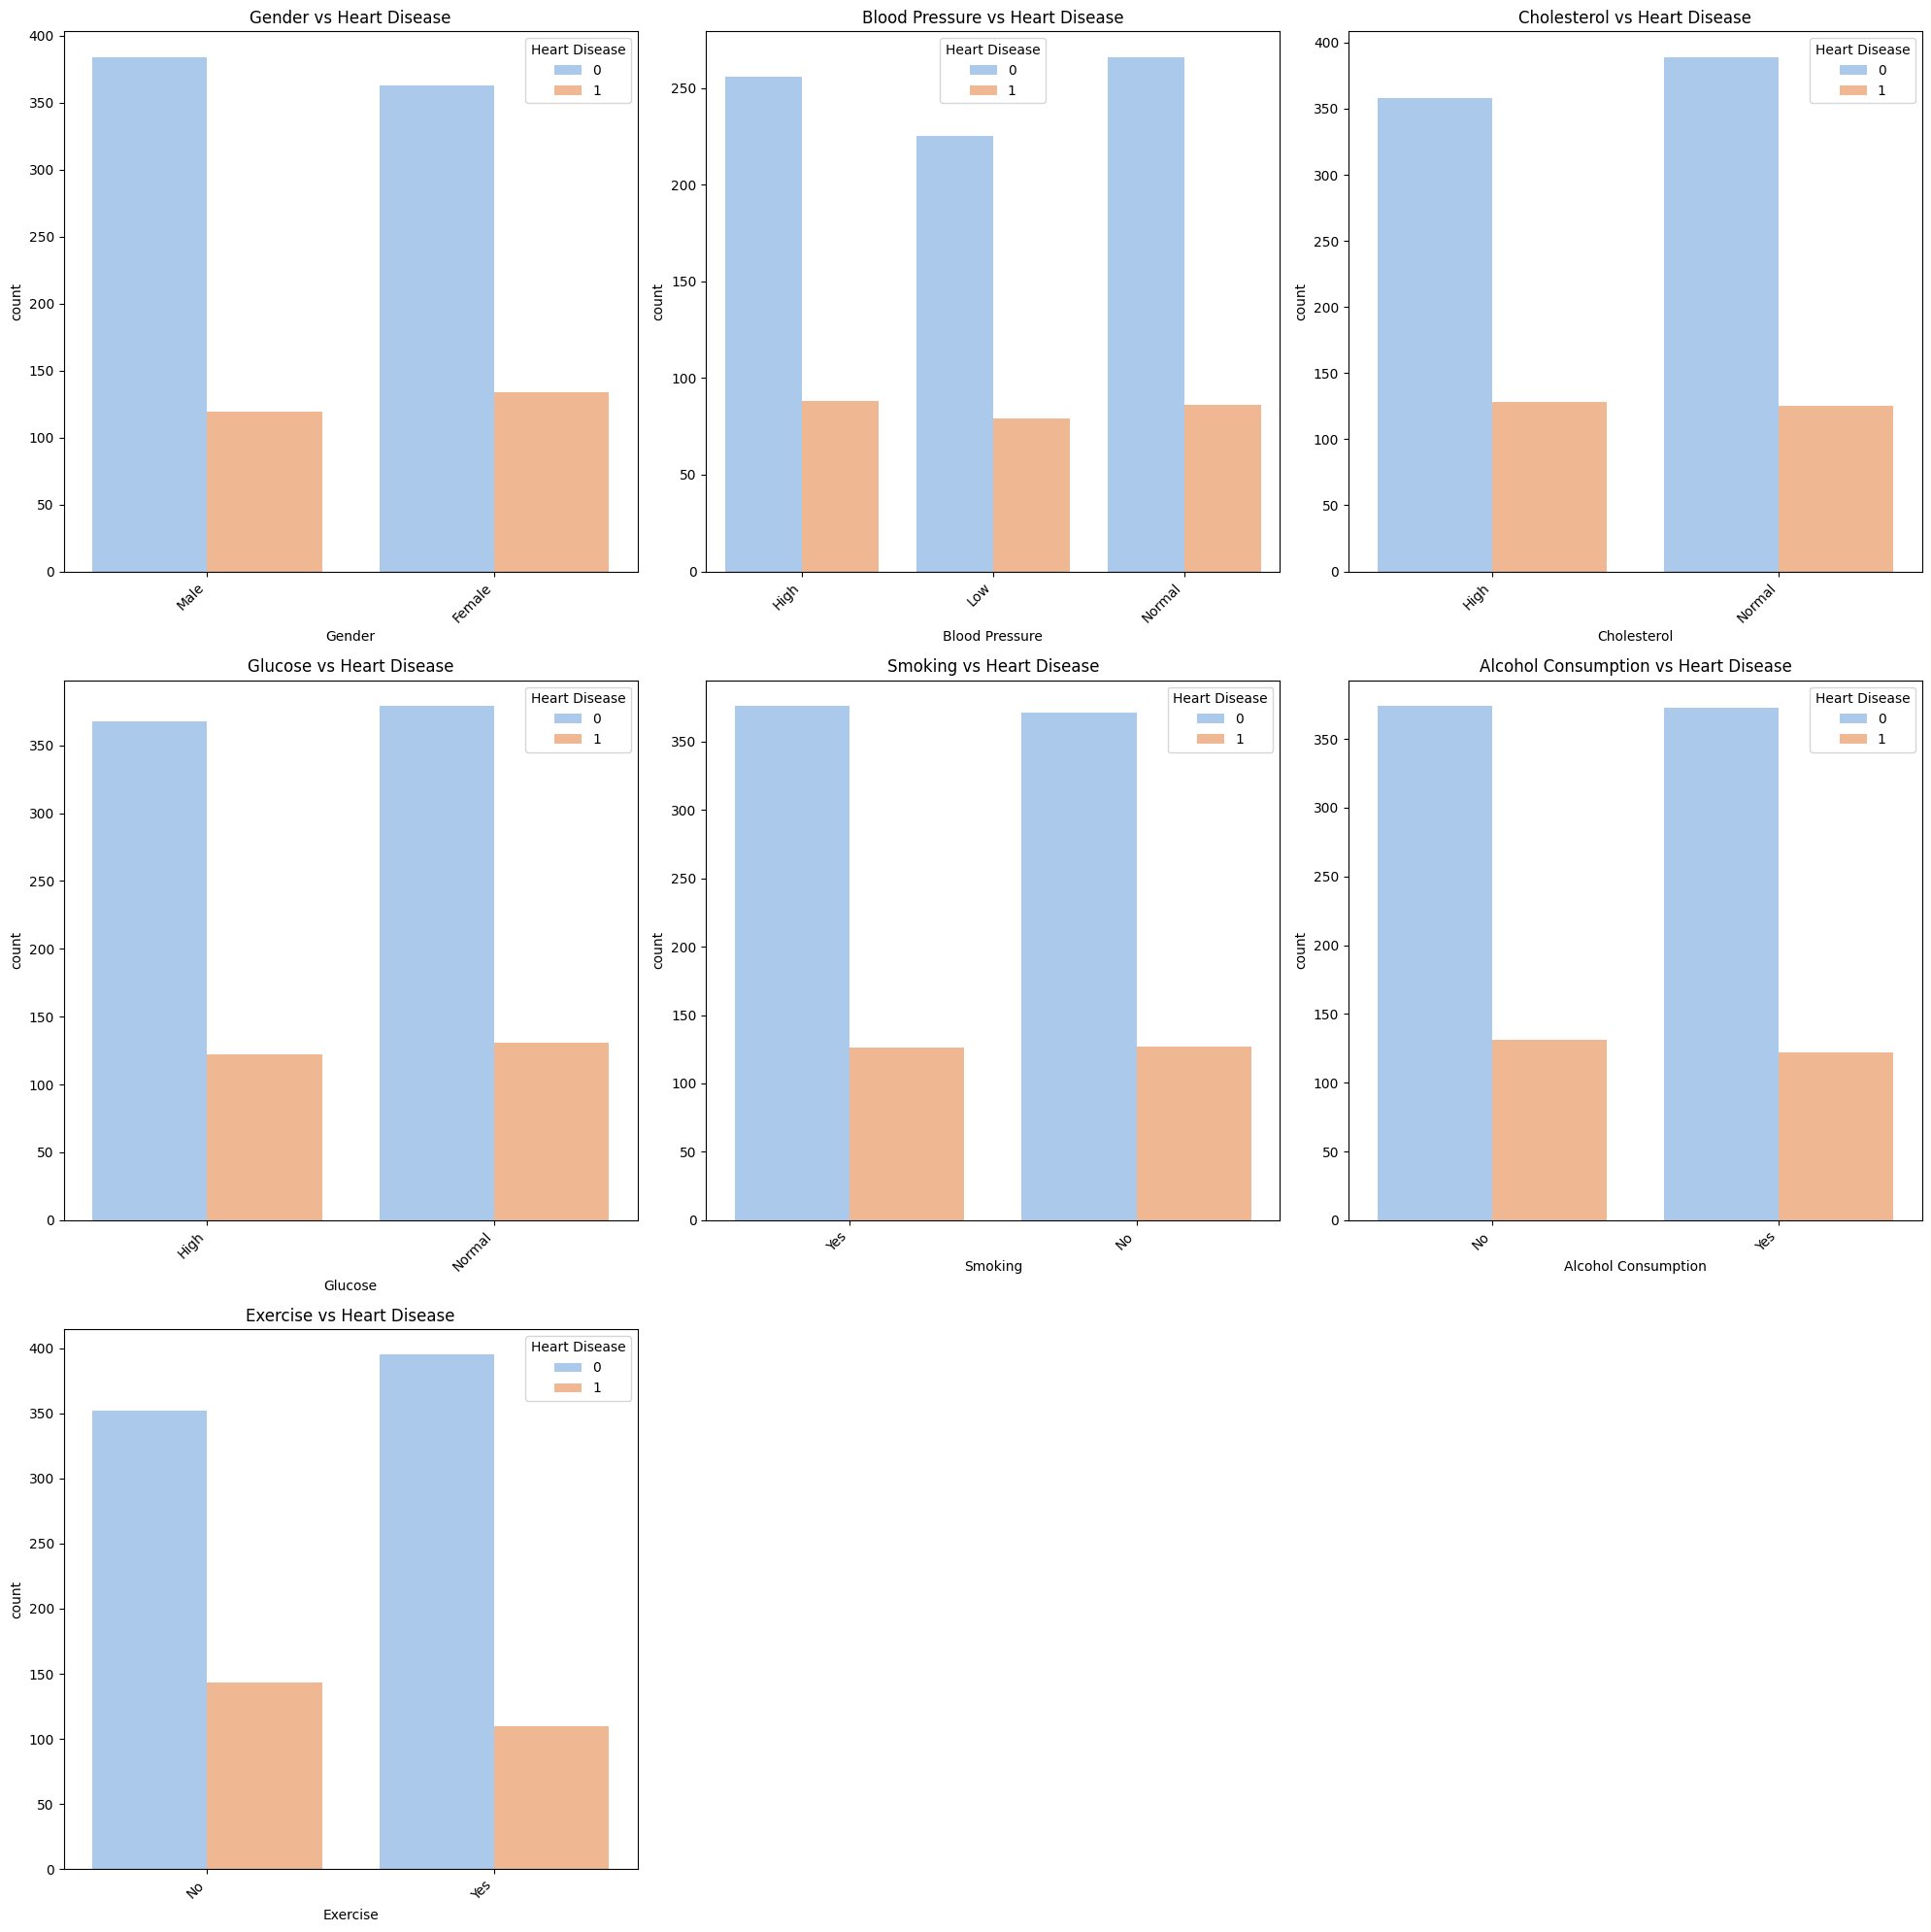

In [42]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(categorical_cols[:-1]):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, hue='Heart Disease', data=df, palette='pastel')
    plt.title(f'{col} vs Heart Disease')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

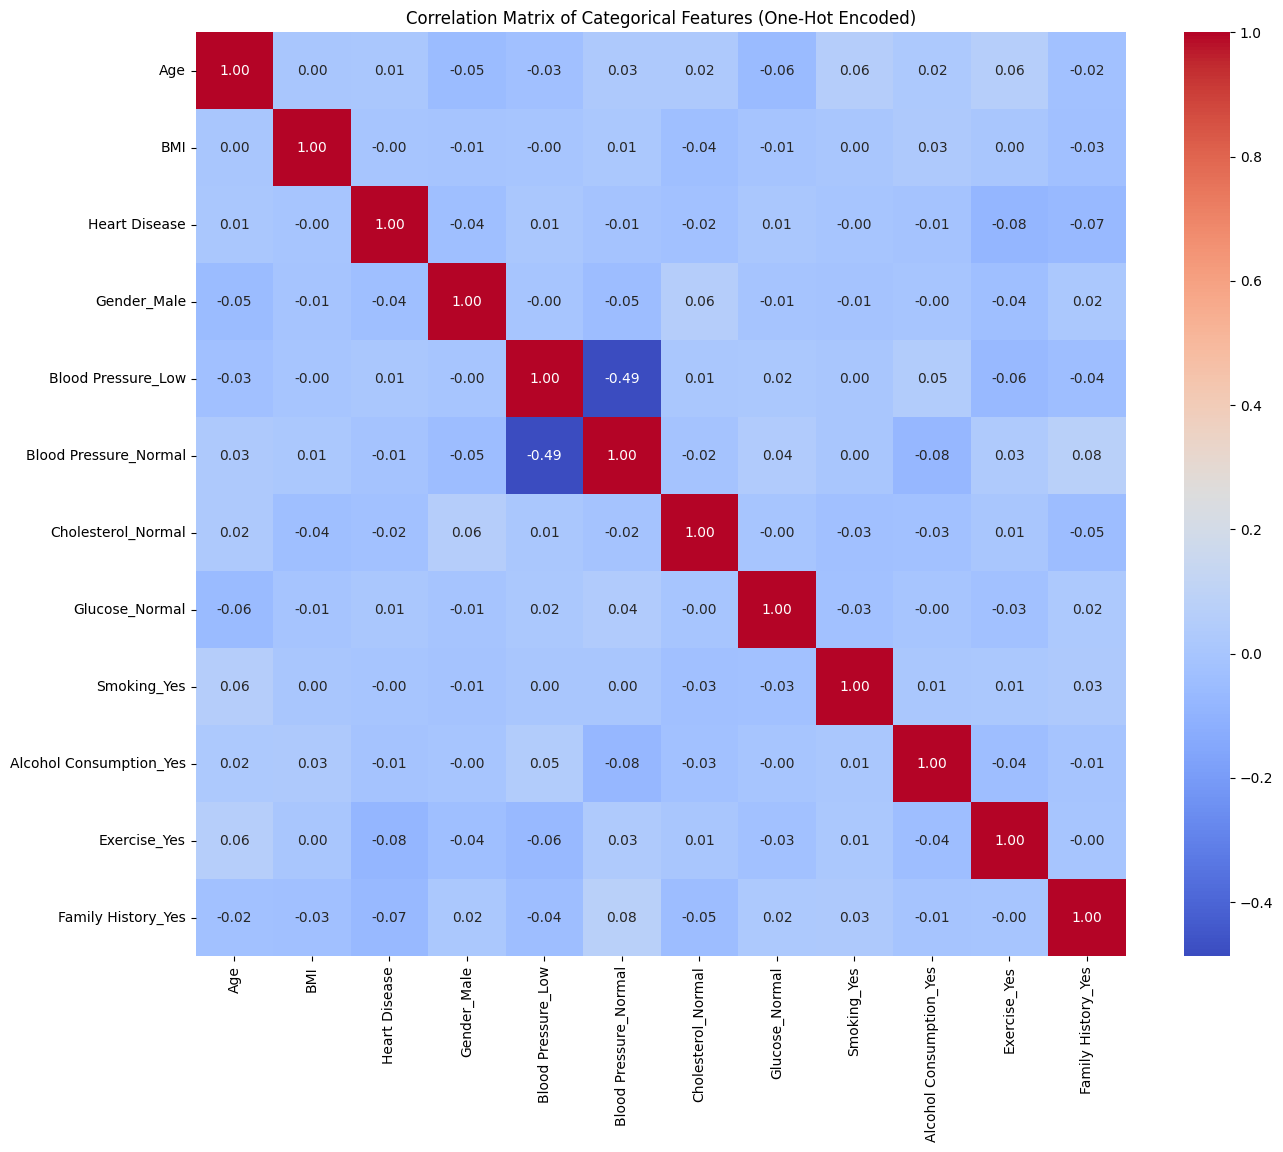

In [43]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

plt.figure(figsize=(15, 12))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Categorical Features (One-Hot Encoded)')
plt.show()

### ETL: Data Preparation for Machine Learning

In [44]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

display(X.head())
display(y.head())

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History
0,69,Male,High,High,High,Yes,No,No,35.671099,No
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No


,Heart Disease
0,1
1,0
2,1
3,0
4,0


In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 10)
X_test shape: (200, 10)
y_train shape: (800,)
y_test shape: (200,)


In [46]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['Age', 'BMI']
Categorical columns: ['Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking', 'Alcohol Consumption', 'Exercise', 'Family History']


In [47]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (800, 19)
X_test_processed shape: (200, 19)


### Model Training: Logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

log_reg_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Model Prediction and Evaluation

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = log_reg_model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7100
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Confusion Matrix:
[[142   0]
 [ 58   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       142
           1       0.00      0.00      0.00        58

    accuracy                           0.71       200
   macro avg       0.35      0.50      0.42       200
weighted avg       0.50      0.71      0.59       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

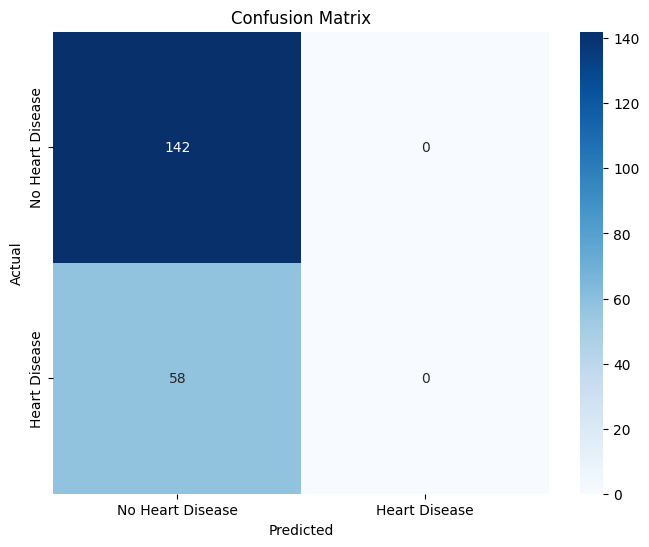

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Model Training: Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Random Forest Model Prediction and Evaluation

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_rf = rf_model.predict(X_test_processed)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6950
Random Forest Precision: 0.3333
Random Forest Recall: 0.0517
Random Forest F1-Score: 0.0896

Random Forest Confusion Matrix:
[[136   6]
 [ 55   3]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.96      0.82       142
           1       0.33      0.05      0.09        58

    accuracy                           0.69       200
   macro avg       0.52      0.50      0.45       200
weighted avg       0.60      0.69      0.61       200



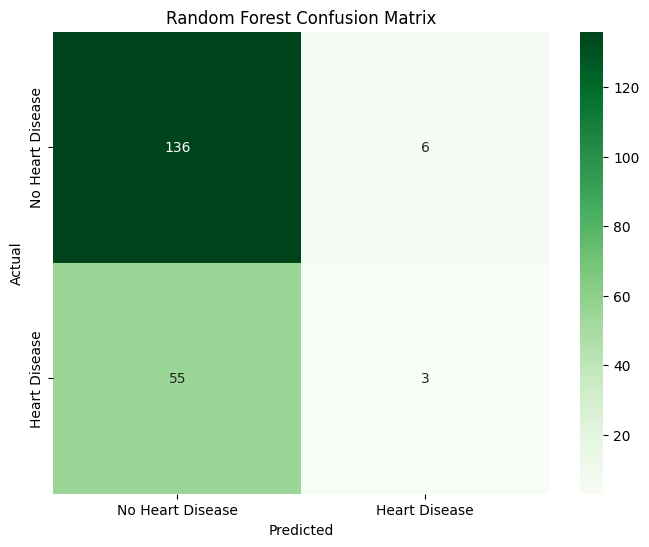

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Model Training: Decision Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


### Decision Tree Model Prediction and Evaluation

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_dt = dt_model.predict(X_test_processed)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Precision: {precision_dt:.4f}")
print(f"Decision Tree Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

print("\nDecision Tree Confusion Matrix:")
print(conf_matrix_dt)

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5800
Decision Tree Precision: 0.2593
Decision Tree Recall: 0.2414
Decision Tree F1-Score: 0.2500

Decision Tree Confusion Matrix:
[[102  40]
 [ 44  14]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       142
           1       0.26      0.24      0.25        58

    accuracy                           0.58       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.57      0.58      0.58       200



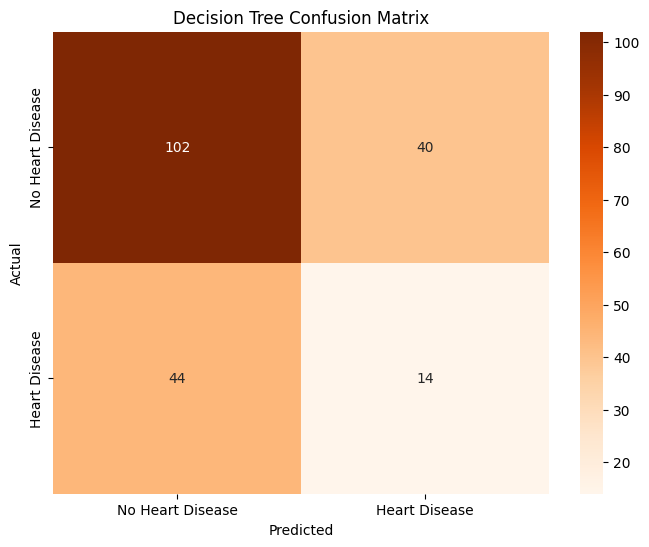

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

### Model Training: XGBoost

In [65]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train_processed, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:22:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_xgb = xgb_model.predict(X_test_processed)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

print("\nXGBoost Confusion Matrix:")
print(conf_matrix_xgb)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6550
XGBoost Precision: 0.3226
XGBoost Recall: 0.1724
XGBoost F1-Score: 0.2247

XGBoost Confusion Matrix:
[[121  21]
 [ 48  10]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       142
           1       0.32      0.17      0.22        58

    accuracy                           0.66       200
   macro avg       0.52      0.51      0.50       200
weighted avg       0.60      0.66      0.62       200



### Model Comparison

In [67]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_dt, accuracy_xgb],
    'Precision': [precision, precision_rf, precision_dt, precision_xgb],
    'Recall': [recall, recall_rf, recall_dt, recall_xgb],
    'F1-Score': [f1, f1_rf, f1_dt, f1_xgb]
})

display(model_comparison.sort_values(by='Accuracy', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.710,0.000000,0.000000,0.000000
1,Random Forest,0.695,0.333333,0.051724,0.089552
3,XGBoost,0.655,0.322581,0.172414,0.224719
2,Decision Tree,0.580,0.259259,0.241379,0.250000


### Test on New Data Sample

In [68]:
import pandas as pd

new_data = pd.DataFrame({
    'Age': [55],
    'Gender': ['Female'],
    'Blood Pressure': ['Normal'],
    'Cholesterol': ['Normal'],
    'Glucose': ['Normal'],
    'Smoking': ['No'],
    'Alcohol Consumption': ['No'],
    'Exercise': ['Yes'],
    'BMI': [25.5],
    'Family History': ['No']
})

display(new_data)

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History
0,55,Female,Normal,Normal,Normal,No,No,Yes,25.5,No


In [69]:
new_data_processed = preprocessor.transform(new_data)

print(f"Shape of processed new data: {new_data_processed.shape}")

Shape of processed new data: (1, 19)


In [70]:
log_reg_prediction = log_reg_model.predict(new_data_processed)
rf_prediction = rf_model.predict(new_data_processed)
dt_prediction = dt_model.predict(new_data_processed)
xgb_prediction = xgb_model.predict(new_data_processed)

print(f"Logistic Regression Prediction: {'Heart Disease' if log_reg_prediction[0] == 1 else 'No Heart Disease'}")
print(f"Random Forest Prediction: {'Heart Disease' if rf_prediction[0] == 1 else 'No Heart Disease'}")
print(f"Decision Tree Prediction: {'Heart Disease' if dt_prediction[0] == 1 else 'No Heart Disease'}")
print(f"XGBoost Prediction: {'Heart Disease' if xgb_prediction[0] == 1 else 'No Heart Disease'}")

Logistic Regression Prediction: No Heart Disease
Random Forest Prediction: No Heart Disease
Decision Tree Prediction: No Heart Disease
XGBoost Prediction: No Heart Disease
